<a href="https://colab.research.google.com/github/positivefunctionIN/Medical_Imaging_using_CNN/blob/main/Medical_Imaging_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install kaggle -q #Intialization

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from google.colab import files

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [9]:
import os   #using API token
os.environ["KAGGLE_API_TOKEN"] = "KGAT_5b435f7615b49cc51191f5ab984c36d2"

In [10]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia
!unzip -q chest-xray-pneumonia.zip -d chest_xray_data

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:20<00:00, 123MB/s]



In [11]:
data_path = "/content/chest_xray_data/chest_xray"

In [12]:
print("Dataset structure:")
print("Train:", os.listdir(f"{data_path}/train"))
print("Test:", os.listdir(f"{data_path}/test"))
print("Val:", os.listdir(f"{data_path}/val"))

Dataset structure:
Train: ['NORMAL', 'PNEUMONIA']
Test: ['NORMAL', 'PNEUMONIA']
Val: ['NORMAL', 'PNEUMONIA']


In [13]:
train_normal = len(os.listdir(f"{data_path}/train/NORMAL"))
train_pneumonia = len(os.listdir(f"{data_path}/train/PNEUMONIA"))
test_normal = len(os.listdir(f"{data_path}/test/NORMAL"))
test_pneumonia = len(os.listdir(f"{data_path}/test/PNEUMONIA"))

print(f"\n📊 Training set:")
print(f"   Normal: {train_normal}")
print(f"   Pneumonia: {train_pneumonia}")
print(f"\n📊 Test set:")
print(f"   Normal: {test_normal}")
print(f"   Pneumonia: {test_pneumonia}")


📊 Training set:
   Normal: 1341
   Pneumonia: 3875

📊 Test set:
   Normal: 234
   Pneumonia: 390


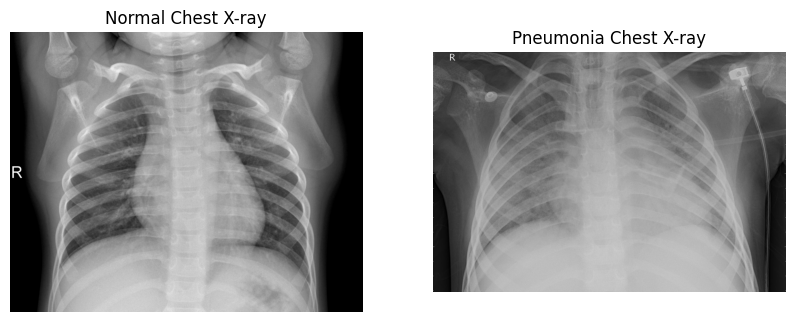

✅ Dataset explored


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

normal_sample = plt.imread(f"{data_path}/train/NORMAL/" + os.listdir(f"{data_path}/train/NORMAL")[0])
pneumonia_sample = plt.imread(f"{data_path}/train/PNEUMONIA/" + os.listdir(f"{data_path}/train/PNEUMONIA")[0])

axes[0].imshow(normal_sample, cmap='gray')
axes[0].set_title("Normal Chest X-ray")
axes[0].axis('off')

axes[1].imshow(pneumonia_sample, cmap='gray')
axes[1].set_title("Pneumonia Chest X-ray")
axes[1].axis('off')

plt.show()
print("✅ Dataset explored")


In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(rescale=1./255)

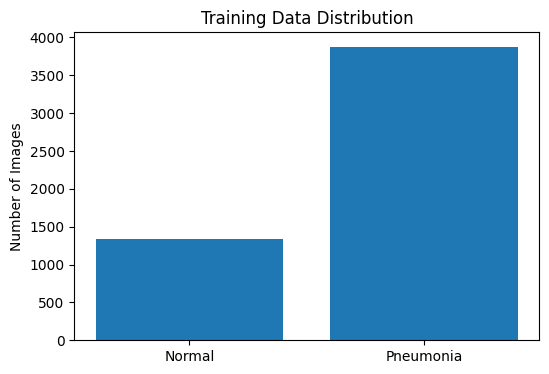

In [16]:
labels = ['Normal', 'Pneumonia']
counts = [train_normal, train_pneumonia]

plt.figure(figsize=(6,4))
plt.bar(labels, counts)
plt.title("Training Data Distribution")
plt.ylabel("Number of Images")
plt.show()

In [17]:
train_generator = train_datagen.flow_from_directory(
    f"{data_path}/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    f"{data_path}/train",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    f"{data_path}/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [18]:
print(train_generator.class_indices)

{'NORMAL': 0, 'PNEUMONIA': 1}


In [19]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

In [20]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [21]:
model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [22]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5
)

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(['Train','Validation'])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(['Train','Validation'])

plt.show()